# 2. Single-System Feature Selection

This notebook explores the cleaned output of notebook 1 for one system and ranks candidate features against the DC-power target. Statistics and correlations are computed on the full cleaned dataset; robustness of the model metrics is checked later with cross-validation over multiple random states. The cleaned CSV is read only and is never modified here.

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

PROJECT_ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "data" / "cleaned").is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the thesis project root.")

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "metrics"
print(f"Project root: {PROJECT_ROOT}")

Project root: /home/raul/Desktop/solar-data-all/thesis


## 1. Load the cleaned data

Load the selected system's cleaned CSV written by notebook 1. `TARGET` is the DC-power column; every other numeric column except `system_id` becomes a candidate feature. `datetime` is parsed but not used as a feature.

In [2]:
# Select the system and target column.
SYSTEM_ID = 4
TARGET = "dc_power__314"

INPUT_PATH = PROJECT_ROOT / "data" / "cleaned" / f"system_{SYSTEM_ID}_cleaned.csv"
if not INPUT_PATH.is_file():
    raise FileNotFoundError(f"Cleaned data not found: {INPUT_PATH}; run notebook 1 first.")

df = pd.read_csv(INPUT_PATH, low_memory=False)
df["datetime"] = pd.to_datetime(df["datetime"], errors="raise")
if TARGET not in df.columns:
    raise KeyError(f"TARGET not found in {INPUT_PATH.name}: {TARGET}")

FEATURES = [
    column
    for column in df.select_dtypes(include="number").columns
    if column not in {TARGET, "system_id"}
]
analysis_columns = [TARGET, *FEATURES]
remaining_missing = int(df[analysis_columns].isna().sum().sum())
if remaining_missing:
    raise ValueError(f"Cleaned data still has {remaining_missing:,} missing values.")

print(f"System selected: {SYSTEM_ID}")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['datetime'].min()} -> {df['datetime'].max()}")
print(f"Target: {TARGET}")
print(f"Candidate features ({len(FEATURES)}): {FEATURES}")
display(df.head())

System selected: 4
Loaded: 1,463,640 rows x 7 columns
Date range: 2007-08-26 10:15:00 -> 2023-01-31 16:49:00
Target: dc_power__314
Candidate features (4): ['poa_irradiance__313', 'module_temp_1__321', 'ambient_temp__320', 'das_temp__325']


,system_id,datetime,dc_power__314,poa_irradiance__313,module_temp_1__321,ambient_temp__320,das_temp__325
0,4,2007-08-26 10:15:00,124.768,990.0,51.635,28.936,36.045
1,4,2007-08-26 10:30:00,788.769,963.0,51.005,28.979,36.742
2,4,2007-08-26 10:45:00,748.326,280.0,49.709,29.261,37.172
3,4,2007-08-26 11:00:00,868.251,160.0,53.407,29.433,37.538
4,4,2007-08-26 11:15:00,823.090,949.0,55.088,29.951,38.160


## 2. Basic statistics

Summarize the target and every candidate feature: location (mean, median), spread (std, variance, IQR, range, coefficient of variation), percentiles, shape (skewness, excess kurtosis), and value counts (unique, zero, negative). `NEAR_CONSTANT_CV` and `HIGH_SKEW` flag columns that may carry little information or need a transform later; nothing is dropped here.

In [3]:
# Flag thresholds for this stage.
NEAR_CONSTANT_CV = 0.01
HIGH_SKEW = 1.0
PERCENTILES = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]

values = df[analysis_columns]
percentile_table = values.quantile(PERCENTILES).T
percentile_table.columns = [f"p{round(p * 100):02d}" for p in PERCENTILES]

stats_table = pd.DataFrame(
    {
        "count": values.count(),
        "mean": values.mean(),
        "std": values.std(),
        "variance": values.var(),
        "min": values.min(),
        "max": values.max(),
        "range": values.max() - values.min(),
        "iqr": percentile_table["p75"] - percentile_table["p25"],
        "cv": values.std() / values.mean().abs(),
        "skewness": values.skew(),
        "excess_kurtosis": values.kurt(),
        "unique_values": values.nunique(),
        "zero_values": values.eq(0).sum(),
        "negative_values": values.lt(0).sum(),
    }
).join(percentile_table)
stats_table = stats_table[
    [
        "count", "mean", "std", "variance", "min", *percentile_table.columns,
        "max", "range", "iqr", "cv", "skewness", "excess_kurtosis",
        "unique_values", "zero_values", "negative_values",
    ]
]
stats_table["near_constant"] = stats_table["cv"].lt(NEAR_CONSTANT_CV)
stats_table["high_skew"] = stats_table["skewness"].abs().gt(HIGH_SKEW)

STATS_PATH = ARTIFACTS_DIR / f"system_{SYSTEM_ID}_feature_statistics.csv"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
stats_table.to_csv(STATS_PATH, index_label="column")

with pd.option_context("display.max_columns", None, "display.width", 200):
    display(stats_table.T.round(3))
print(f"Near-constant columns (cv < {NEAR_CONSTANT_CV}): "
      f"{stats_table.index[stats_table['near_constant']].tolist()}")
print(f"Highly skewed columns (|skew| > {HIGH_SKEW}): "
      f"{stats_table.index[stats_table['high_skew']].tolist()}")
print(f"Statistics saved to: {STATS_PATH}")

,dc_power__314,poa_irradiance__313,module_temp_1__321,ambient_temp__320,das_temp__325
count,1463640,1463640,1463640,1463640,1463640
mean,440.75142,513.529372,26.142749,14.821577,20.676792
std,317.249775,362.90494,13.644707,9.809429,11.041018
variance,100647.419535,131699.995657,186.17804,96.224902,121.904068
min,20.0,-4.1555,-23.688,-24.5885,-24.7614
p01,22.156744,25.042147,-4.086907,-8.489583,-4.4061
p05,31.393845,41.751964,3.323493,-1.649205,2.057399
p25,135.57205,171.3231,16.249897,7.654295,12.57891
p50,395.24275,456.0302,26.36923,15.280745,21.1125
p75,746.939725,858.4584,36.293948,22.6005,29.39725


Near-constant columns (cv < 0.01): []
Highly skewed columns (|skew| > 1.0): []
Statistics saved to: /home/raul/Desktop/solar-data-all/thesis/artifacts/metrics/system_4_feature_statistics.csv


## 3. Distributions

Plot a histogram and a box plot for the target and each candidate feature, each on its own axis because units differ. Histograms use all rows; dashed and dotted lines mark the mean and median. Box-plot whiskers extend to 1.5 × IQR, and points beyond them are drawn as small outlier markers.

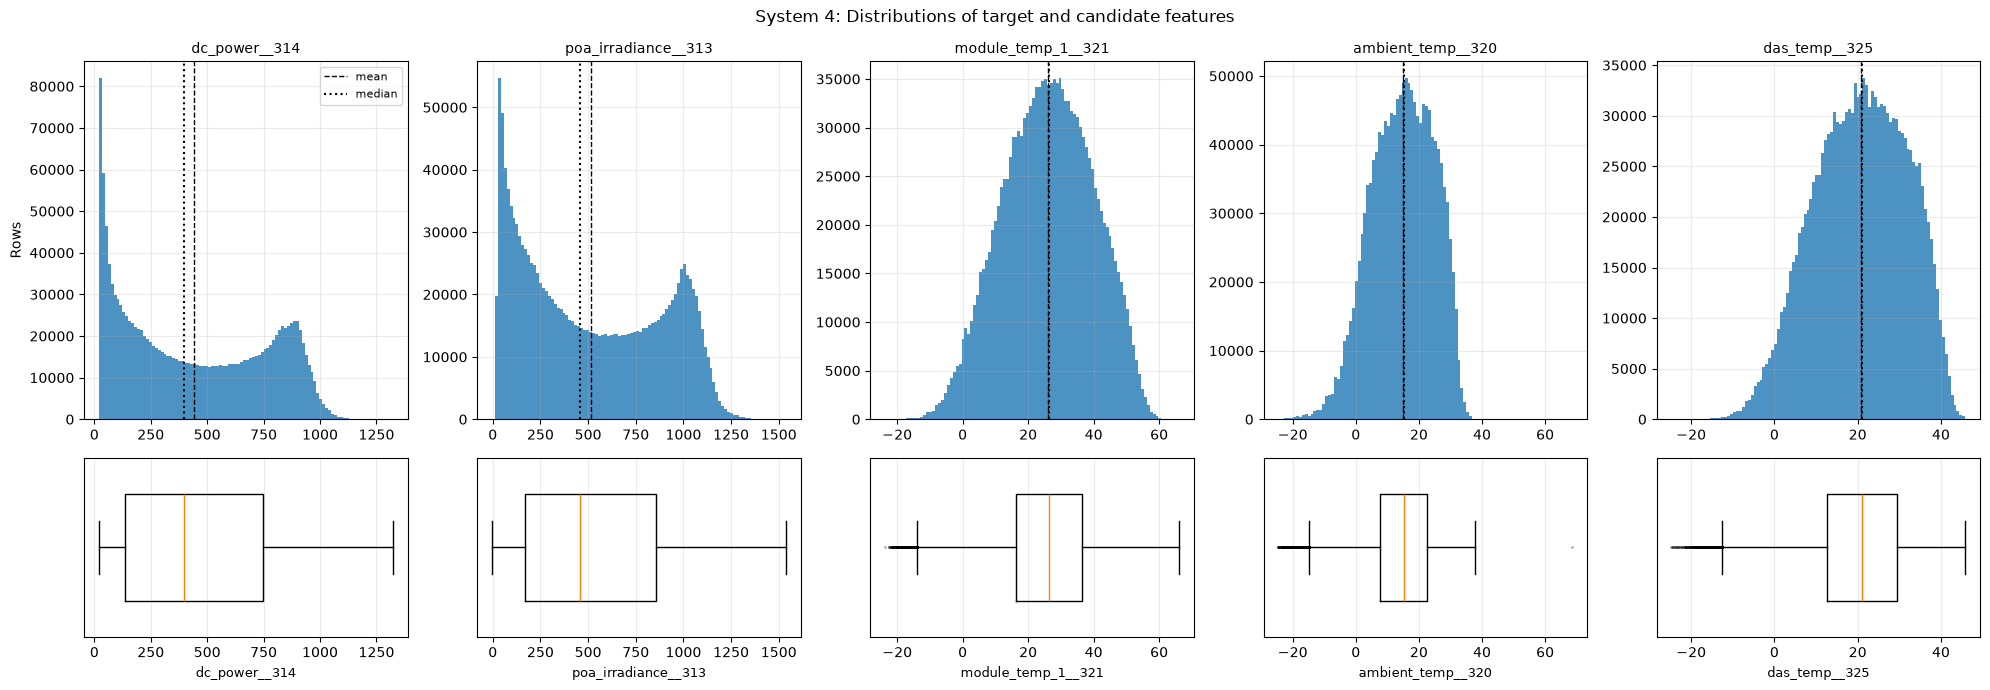

Distribution plot saved to: /home/raul/Desktop/solar-data-all/thesis/artifacts/metrics/system_4_feature_distributions.png


In [4]:
# Plot settings for this stage.
HIST_BINS = 100

DIST_PLOT_PATH = ARTIFACTS_DIR / f"system_{SYSTEM_ID}_feature_distributions.png"
n_columns = len(analysis_columns)
fig, axes = plt.subplots(
    2, n_columns, figsize=(4 * n_columns, 7), gridspec_kw={"height_ratios": [2, 1]}
)
axes = np.asarray(axes).reshape(2, n_columns)

for index, column in enumerate(analysis_columns):
    hist_ax, box_ax = axes[0, index], axes[1, index]
    column_values = df[column].to_numpy()

    hist_ax.hist(column_values, bins=HIST_BINS, color="tab:blue", alpha=0.8)
    hist_ax.axvline(stats_table.loc[column, "mean"], color="black", linestyle="--",
                    linewidth=1, label="mean")
    hist_ax.axvline(stats_table.loc[column, "p50"], color="black", linestyle=":",
                    linewidth=1.5, label="median")
    hist_ax.set_title(column, fontsize=10)
    hist_ax.set_ylabel("Rows" if index == 0 else "")
    hist_ax.grid(True, alpha=0.25)

    box_ax.boxplot(
        column_values,
        orientation="horizontal",
        widths=0.6,
        flierprops={"marker": ".", "markersize": 2, "alpha": 0.3, "rasterized": True},
    )
    box_ax.set_yticks([])
    box_ax.set_xlabel(column, fontsize=9)
    box_ax.grid(True, axis="x", alpha=0.25)

axes[0, 0].legend(fontsize=8)
fig.suptitle(f"System {SYSTEM_ID}: Distributions of target and candidate features")
fig.tight_layout()

fig.savefig(DIST_PLOT_PATH, dpi=160)
plt.show()
print(f"Distribution plot saved to: {DIST_PLOT_PATH}")

## 4. Pearson correlation with the target

Compute Pearson r between each candidate feature and `TARGET`, ranked by |r|. Spearman ρ is shown alongside: when it is much higher than |r|, the relationship is monotonic but not linear. Features with |r| below `MIN_ABS_CORR` are flagged as weak; nothing is dropped in this stage.

,pearson_r,abs_pearson_r,spearman_rho,r_squared,weak
feature,,,,,
poa_irradiance__313,0.9716,0.9716,0.9678,0.9440,False
module_temp_1__321,0.6611,0.6611,0.6656,0.4371,False
das_temp__325,0.2711,0.2711,0.2645,0.0735,True
ambient_temp__320,0.1270,0.1270,0.1146,0.0161,True


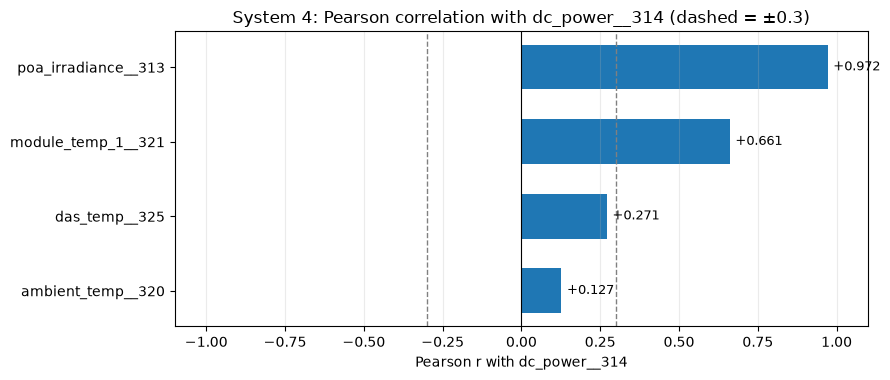

Weak features (|r| < 0.3): ['das_temp__325', 'ambient_temp__320']
Correlation table saved to: /home/raul/Desktop/solar-data-all/thesis/artifacts/metrics/system_4_pearson_dc_power__314.csv
Correlation plot saved to: /home/raul/Desktop/solar-data-all/thesis/artifacts/metrics/system_4_pearson_dc_power__314.png


In [5]:
# Correlation threshold for flagging weak features.
MIN_ABS_CORR = 0.3

pearson_r = df[FEATURES].corrwith(df[TARGET], method="pearson")
spearman_rho = df[FEATURES].corrwith(df[TARGET], method="spearman")
correlation_table = (
    pd.DataFrame(
        {
            "pearson_r": pearson_r,
            "abs_pearson_r": pearson_r.abs(),
            "spearman_rho": spearman_rho,
            "r_squared": pearson_r**2,
        }
    )
    .sort_values("abs_pearson_r", ascending=False)
    .rename_axis("feature")
)
correlation_table["weak"] = correlation_table["abs_pearson_r"].lt(MIN_ABS_CORR)

CORR_TABLE_PATH = ARTIFACTS_DIR / f"system_{SYSTEM_ID}_pearson_{TARGET}.csv"
CORR_PLOT_PATH = ARTIFACTS_DIR / f"system_{SYSTEM_ID}_pearson_{TARGET}.png"
correlation_table.to_csv(CORR_TABLE_PATH)
display(correlation_table.round(4))

plot_order = correlation_table.iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 0.6 * len(plot_order) + 1.5))
ax.barh(plot_order.index, plot_order["pearson_r"], color="tab:blue", height=0.6)
for feature, r in plot_order["pearson_r"].items():
    ax.annotate(
        f"{r:+.3f}",
        (r, feature),
        xytext=(4 if r >= 0 else -4, 0),
        textcoords="offset points",
        ha="left" if r >= 0 else "right",
        va="center",
        fontsize=9,
    )
for threshold in (-MIN_ABS_CORR, MIN_ABS_CORR):
    ax.axvline(threshold, color="gray", linestyle="--", linewidth=1)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(-1.1, 1.1)
ax.set_xlabel(f"Pearson r with {TARGET}")
ax.set_title(f"System {SYSTEM_ID}: Pearson correlation with {TARGET} "
             f"(dashed = ±{MIN_ABS_CORR:g})")
ax.grid(True, axis="x", alpha=0.25)
fig.tight_layout()

fig.savefig(CORR_PLOT_PATH, dpi=160)
plt.show()
print(f"Weak features (|r| < {MIN_ABS_CORR:g}): "
      f"{correlation_table.index[correlation_table['weak']].tolist()}")
print(f"Correlation table saved to: {CORR_TABLE_PATH}")
print(f"Correlation plot saved to: {CORR_PLOT_PATH}")

## 5. Correlation heatmap

Pearson r between every pair of columns, target included. The target row repeats section 4. The off-diagonal feature pairs show redundancy: two features with |r| above `COLLINEAR_THRESHOLD` carry mostly the same information, so a model gains little from keeping both. The colour scale is diverging and fixed to [-1, 1] with white at 0, so the sign and strength of each cell can be read directly.

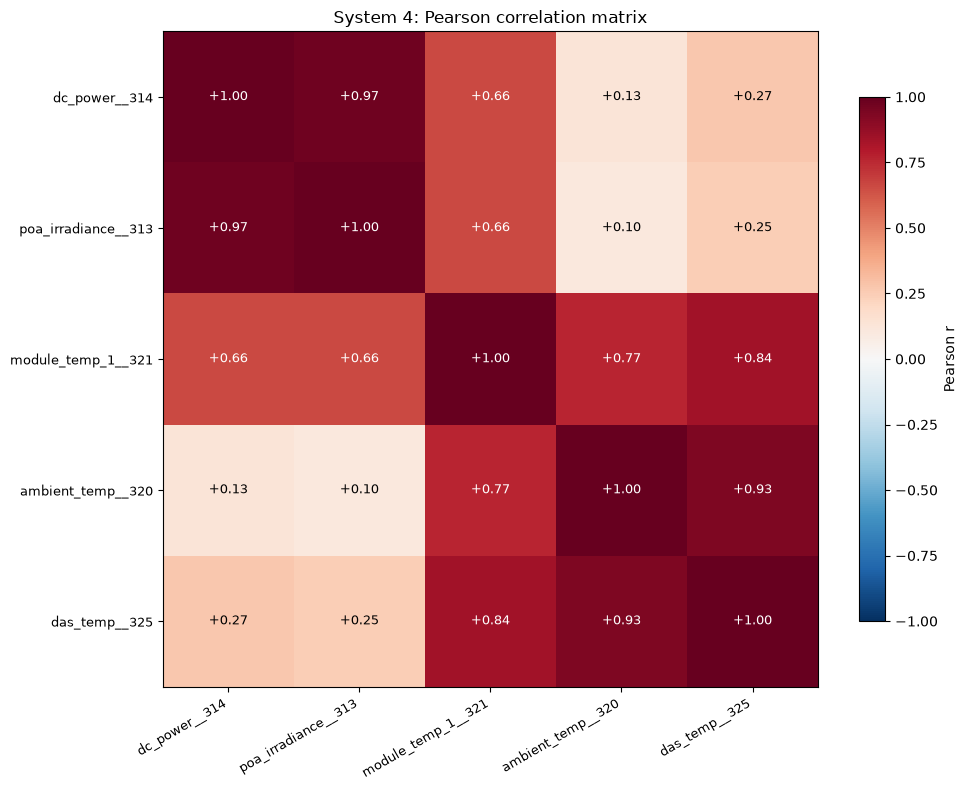

Collinear feature pairs (|r| > 0.9): [('ambient_temp__320', 'das_temp__325', 0.933)]
Correlation matrix saved to: /home/raul/Desktop/solar-data-all/thesis/artifacts/metrics/system_4_correlation_matrix.csv
Correlation heatmap saved to: /home/raul/Desktop/solar-data-all/thesis/artifacts/metrics/system_4_correlation_heatmap.png


In [6]:
# Pairs above this |r| are flagged as collinear.
COLLINEAR_THRESHOLD = 0.9

corr_matrix = df[analysis_columns].corr(method="pearson")

HEATMAP_TABLE_PATH = ARTIFACTS_DIR / f"system_{SYSTEM_ID}_correlation_matrix.csv"
HEATMAP_PLOT_PATH = ARTIFACTS_DIR / f"system_{SYSTEM_ID}_correlation_heatmap.png"
corr_matrix.to_csv(HEATMAP_TABLE_PATH)

n_matrix = len(analysis_columns)
fig, ax = plt.subplots(figsize=(1.6 * n_matrix + 2, 1.4 * n_matrix + 1))
image = ax.imshow(corr_matrix.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
for row in range(n_matrix):
    for col in range(n_matrix):
        r = corr_matrix.iat[row, col]
        ax.text(col, row, f"{r:+.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(r) > 0.6 else "black")
ax.set_xticks(range(n_matrix), corr_matrix.columns, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(n_matrix), corr_matrix.index, fontsize=9)
fig.colorbar(image, ax=ax, label="Pearson r", shrink=0.8)
ax.set_title(f"System {SYSTEM_ID}: Pearson correlation matrix")
fig.tight_layout()

fig.savefig(HEATMAP_PLOT_PATH, dpi=160)
plt.show()

feature_pairs = [
    (a, b, corr_matrix.loc[a, b])
    for i, a in enumerate(FEATURES)
    for b in FEATURES[i + 1:]
]
collinear_pairs = [
    (a, b, round(float(r), 3)) for a, b, r in feature_pairs if abs(r) > COLLINEAR_THRESHOLD
]
print(f"Collinear feature pairs (|r| > {COLLINEAR_THRESHOLD:g}): {collinear_pairs}")
print(f"Correlation matrix saved to: {HEATMAP_TABLE_PATH}")
print(f"Correlation heatmap saved to: {HEATMAP_PLOT_PATH}")

## 6. Scatter plots per feature

Plot `TARGET` against each candidate feature to see the shape of each relationship: a straight band means Pearson r describes it well, while curvature, fans or separate clusters point to non-linear effects or data issues. With about 1.5 million rows a full scatter is one solid blob, so each panel draws a fixed random sample of `SCATTER_SAMPLE` rows with small, translucent markers. The same sample is used in every panel.

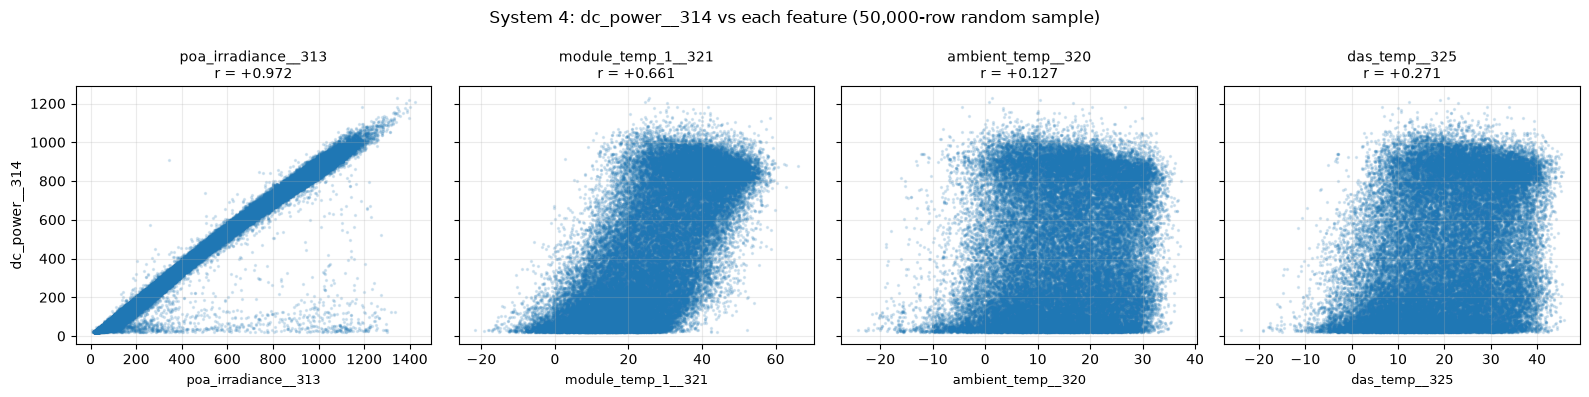

Scatter plot saved to: /home/raul/Desktop/solar-data-all/thesis/artifacts/metrics/system_4_scatter_dc_power__314.png


In [7]:
# Sample size and seed for the scatter plots.
SCATTER_SAMPLE = 50_000
SCATTER_SEED = 42

sample = df.sample(n=min(SCATTER_SAMPLE, len(df)), random_state=SCATTER_SEED)
SCATTER_PLOT_PATH = ARTIFACTS_DIR / f"system_{SYSTEM_ID}_scatter_{TARGET}.png"

n_features = len(FEATURES)
fig, axes = plt.subplots(1, n_features, figsize=(4 * n_features, 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, feature in zip(axes, FEATURES):
    ax.scatter(sample[feature], sample[TARGET], s=2, alpha=0.15, color="tab:blue",
               rasterized=True)
    ax.set_title(f"{feature}\nr = {correlation_table.loc[feature, 'pearson_r']:+.3f}",
                 fontsize=10)
    ax.set_xlabel(feature, fontsize=9)
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel(TARGET)
fig.suptitle(f"System {SYSTEM_ID}: {TARGET} vs each feature "
             f"({len(sample):,}-row random sample)")
fig.tight_layout()

fig.savefig(SCATTER_PLOT_PATH, dpi=160)
plt.show()
print(f"Scatter plot saved to: {SCATTER_PLOT_PATH}")

## 7. Feature configurations

Based on sections 4-6, two feature sets are defined side by side so both can be trained and compared on the same target:

- **endogenous**: plant-side measurements only, `poa_irradiance__313` and `module_temp_1__321`. `ambient_temp__320` and `das_temp__325` are dropped.
- **exogenous**: `ambient_temp__320` together with calendar features taken from `datetime`. This config is a placeholder and stays disabled until its datetime features are chosen.

Each config lists its sensor columns in `features` and its calendar features in `datetime_features`. `build_feature_frame` is the only place that turns a config into model inputs.

In [8]:
FEATURE_CONFIGS = {
    "endogenous": {
        "enabled": True,
        "features": ["poa_irradiance__313", "module_temp_1__321"],
        "datetime_features": [],
    },
    "exogenous": {
        "enabled": False,  # TODO: enable once the datetime features are chosen
        "features": ["ambient_temp__320"],
        "datetime_features": [],  # e.g. hour, day_of_year, month (to be decided later)
    },
}


def build_feature_frame(data, config):
    """Return the feature frame X and target frame y for one config, indexed by datetime."""
    indexed = data.set_index("datetime")
    if config["datetime_features"]:
        # Calendar features for the exogenous config will be derived here.
        raise NotImplementedError("Datetime-derived features are not implemented yet.")
    return indexed[config["features"]].copy(), indexed[[TARGET]].copy()


for name, config in FEATURE_CONFIGS.items():
    unknown = sorted(set(config["features"]) - set(FEATURES))
    if unknown:
        raise KeyError(f"Config '{name}' uses unknown features: {unknown}")
    status = "enabled" if config["enabled"] else "disabled"
    print(f"{name} ({status})")
    print(f"  keep: {config['features'] + config['datetime_features']}")
    print(f"  drop: {[f for f in FEATURES if f not in config['features']]}")

endogenous (enabled)
  keep: ['poa_irradiance__313', 'module_temp_1__321']
  drop: ['ambient_temp__320', 'das_temp__325']
exogenous (disabled)
  keep: ['ambient_temp__320']
  drop: ['poa_irradiance__313', 'module_temp_1__321', 'das_temp__325']


## 8. Train/test preparation

Each enabled configuration from section 7 goes through the same steps, one cell per step: build X and y, find a chronological split boundary, split into X/y train/test, fit the scaler on the training features, apply it, and export. Every cell loops over the enabled configs and keeps its results in dictionaries keyed by config name.

### 8.1 Build X and y

`build_feature_frame` returns the feature frame `X` and target frame `y` for a config, indexed by `datetime`. Rows are sorted by time with a stable sort, so the next step can split by position. Disabled configs are listed here and skipped from now on.

In [9]:
ENABLED_CONFIGS = [name for name, config in FEATURE_CONFIGS.items() if config["enabled"]]
for name in FEATURE_CONFIGS.keys() - set(ENABLED_CONFIGS):
    print(f"{name}: not yet implemented, skipped.")

X_sets, y_sets = {}, {}
for name in ENABLED_CONFIGS:
    X, y = build_feature_frame(df, FEATURE_CONFIGS[name])
    X_sets[name] = X.sort_index(kind="stable")
    y_sets[name] = y.sort_index(kind="stable")
    print(f"{name}: X {X_sets[name].shape}, y {y_sets[name].shape}, "
          f"features {list(X_sets[name].columns)}")

exogenous: not yet implemented, skipped.
endogenous: X (1463640, 2), y (1463640, 1), features ['poa_irradiance__313', 'module_temp_1__321']


### 8.2 Chronological split boundary

The first `TRAIN_FRACTION` of rows in time order is used for training and the rest for testing, so the model is always evaluated on data later than anything it has seen. If the boundary row shares its timestamp with earlier rows, the boundary moves back to the first of them, so one timestamp never ends up in both partitions.

In [10]:
# Fraction of rows, in time order, used for training.
TRAIN_FRACTION = 0.8

split_positions = {}
for name in ENABLED_CONFIGS:
    index = X_sets[name].index
    position = int(len(index) * TRAIN_FRACTION)
    position = int(index.searchsorted(index[position], side="left"))
    if not 0 < position < len(index):
        raise ValueError(f"{name}: split leaves an empty partition.")
    split_positions[name] = position
    print(f"{name}: boundary at {index[position]} -> "
          f"{position:,} train rows, {len(index) - position:,} test rows "
          f"({position / len(index):.1%} train)")

endogenous: boundary at 2016-01-20 10:09:00 -> 1,170,912 train rows, 292,728 test rows (80.0% train)


### 8.3 X/y train/test split

Slice X and y at the boundary into `X_train`, `X_test`, `y_train` and `y_test`. The asserts confirm that every partition is non-empty with no missing values, that X and y rows line up, and that all training timestamps come before all test timestamps.

In [11]:
X_train_sets, X_test_sets, y_train_sets, y_test_sets = {}, {}, {}, {}
split_rows = []
for name in ENABLED_CONFIGS:
    position = split_positions[name]
    X_train_sets[name], X_test_sets[name] = X_sets[name].iloc[:position], X_sets[name].iloc[position:]
    y_train_sets[name], y_test_sets[name] = y_sets[name].iloc[:position], y_sets[name].iloc[position:]

    partitions = {
        "X_train": X_train_sets[name], "X_test": X_test_sets[name],
        "y_train": y_train_sets[name], "y_test": y_test_sets[name],
    }
    assert all(not frame.empty and frame.notna().all().all() for frame in partitions.values())
    assert X_train_sets[name].index.equals(y_train_sets[name].index)
    assert X_test_sets[name].index.equals(y_test_sets[name].index)
    assert X_train_sets[name].index.max() < X_test_sets[name].index.min()

    for part, frame in partitions.items():
        split_rows.append({"config": name, "partition": part, "rows": len(frame),
                           "columns": frame.shape[1], "start": frame.index.min(),
                           "end": frame.index.max()})

display(pd.DataFrame(split_rows).set_index(["config", "partition"]))

rows  columns               start                 end
config     partition                                                          
endogenous X_train    1170912        2 2007-08-26 10:15:00 2016-01-20 10:08:00
           X_test      292728        2 2016-01-20 10:09:00 2023-01-31 16:49:00
           y_train    1170912        1 2007-08-26 10:15:00 2016-01-20 10:08:00
           y_test      292728        1 2016-01-20 10:09:00 2023-01-31 16:49:00

### 8.4 Fit the scaler on the training features

A `MinMaxScaler` is fitted on `X_train` only. The minimum and maximum it learns for each feature define the normalization range `(x - min) / (max - min)`. Fitting on the test partition as well would leak information about future data into training.

In [12]:
scalers = {}
for name in ENABLED_CONFIGS:
    scalers[name] = MinMaxScaler().fit(X_train_sets[name])
    learned_range = pd.DataFrame(
        {"train_min": scalers[name].data_min_, "train_max": scalers[name].data_max_,
         "train_range": scalers[name].data_range_},
        index=X_train_sets[name].columns,
    )
    print(f"{name}: learned normalization range")
    display(learned_range.round(4))

endogenous: learned normalization range


,train_min,train_max,train_range
poa_irradiance__313,-4.1555,1537.7480,1541.9035
module_temp_1__321,-23.6880,66.0839,89.7719


### 8.5 Apply the scaling

Transform `X_train` and `X_test` with the fitted scaler, keeping the datetime index and column names. `X_train` lands exactly in [0, 1]. `X_test` can fall slightly outside that range when the test period has values beyond the training extremes; this is expected and is not clipped. The target `y` is left in its original units (W).

In [13]:
def scale(frame, scaler):
    """Apply a fitted scaler and keep the datetime index and column names."""
    return pd.DataFrame(scaler.transform(frame), index=frame.index, columns=frame.columns)


X_train_scaled_sets, X_test_scaled_sets = {}, {}
for name in ENABLED_CONFIGS:
    X_train_scaled_sets[name] = scale(X_train_sets[name], scalers[name])
    X_test_scaled_sets[name] = scale(X_test_sets[name], scalers[name])

    comparison = pd.concat(
        {
            ("X_train", "before"): X_train_sets[name].agg(["min", "max"]).T,
            ("X_train", "after"): X_train_scaled_sets[name].agg(["min", "max"]).T,
            ("X_test", "before"): X_test_sets[name].agg(["min", "max"]).T,
            ("X_test", "after"): X_test_scaled_sets[name].agg(["min", "max"]).T,
        },
        axis=1,
    )
    print(f"{name}: min/max before and after scaling")
    display(comparison.round(4))

endogenous: min/max before and after scaling


X_train                         X_test             \
                      before            after        before              
                         min        max   min  max      min        max   
poa_irradiance__313  -4.1555  1537.7480   0.0  1.0  -3.3598  1494.3790   
module_temp_1__321  -23.6880    66.0839   0.0  1.0 -17.7119    62.5631   

                                     
                      after          
                        min     max  
poa_irradiance__313  0.0005  0.9719  
module_temp_1__321   0.0666  0.9608

### 8.6 Export

Write the scaled features and the unscaled targets to `data/features/group_<system>_<config>/`, and the fitted scaler to `artifacts/models/` so the same transform can be applied to new data later.

In [14]:
FEATURES_DIR = PROJECT_ROOT / "data" / "features"
MODELS_DIR = PROJECT_ROOT / "artifacts" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

for name in ENABLED_CONFIGS:
    group_name = f"group_{SYSTEM_ID}_{name}"
    feature_directory = FEATURES_DIR / group_name
    feature_directory.mkdir(parents=True, exist_ok=True)

    partitions = {
        "X_train": X_train_scaled_sets[name], "X_test": X_test_scaled_sets[name],
        "y_train": y_train_sets[name], "y_test": y_test_sets[name],
    }
    for part, frame in partitions.items():
        frame.to_csv(feature_directory / f"{part}_{group_name}.csv")

    scaler_path = MODELS_DIR / f"scaler_{group_name}.pkl"
    with scaler_path.open("wb") as scaler_file:
        pickle.dump(scalers[name], scaler_file)
    print(f"{name}: wrote {len(partitions)} CSVs to {feature_directory}")
    print(f"{name}: scaler saved to {scaler_path}")

endogenous: wrote 4 CSVs to /home/raul/Desktop/solar-data-all/thesis/data/features/group_4_endogenous
endogenous: scaler saved to /home/raul/Desktop/solar-data-all/thesis/artifacts/models/scaler_group_4_endogenous.pkl


### 8.7 Configuration summary

One row per exported config, saved so notebook 3 can find the training data for each configuration.

In [15]:
config_summary = pd.DataFrame(
    [
        {
            "config": name,
            "group_name": f"group_{SYSTEM_ID}_{name}",
            "features": ", ".join(X_train_sets[name].columns),
            "train_rows": len(X_train_sets[name]),
            "test_rows": len(X_test_sets[name]),
            "train_start": X_train_sets[name].index.min(),
            "train_end": X_train_sets[name].index.max(),
            "test_start": X_test_sets[name].index.min(),
            "test_end": X_test_sets[name].index.max(),
            "feature_directory": FEATURES_DIR / f"group_{SYSTEM_ID}_{name}",
            "scaler_path": MODELS_DIR / f"scaler_group_{SYSTEM_ID}_{name}.pkl",
        }
        for name in ENABLED_CONFIGS
    ]
).set_index("config")

CONFIG_SUMMARY_PATH = ARTIFACTS_DIR / f"system_{SYSTEM_ID}_feature_configs.csv"
config_summary.to_csv(CONFIG_SUMMARY_PATH)
with pd.option_context("display.max_colwidth", None):
    display(config_summary.T)
print(f"Config summary saved to: {CONFIG_SUMMARY_PATH}")

config,endogenous
group_name,group_4_endogenous
features,"poa_irradiance__313, module_temp_1__321"
train_rows,1170912
test_rows,292728
train_start,2007-08-26 10:15:00
train_end,2016-01-20 10:08:00
test_start,2016-01-20 10:09:00
test_end,2023-01-31 16:49:00
feature_directory,/home/raul/Desktop/solar-data-all/thesis/data/features/group_4_endogenous
scaler_path,/home/raul/Desktop/solar-data-all/thesis/artifacts/models/scaler_group_4_endogenous.pkl


Config summary saved to: /home/raul/Desktop/solar-data-all/thesis/artifacts/metrics/system_4_feature_configs.csv
